# lab tasks

In [57]:
X_train = [
  ["Y", "N", "N", "N"],
  ["N", "Y", "N", "N"],
  ["Y", "Y", "N", "N"],
  ["Y", "N", "Y", "Y"],
  ["N", "Y", "Y", "N"]
]
y_train = ["-", "-", "+", "-", "+"]
X_test = [
  ["Y", "Y", "Y", "N"],
  ["N", "N", "N", "N"],
  ["Y", "N", "N", "Y"]
]
y_test = ["+", "-", "-"]

In [58]:
from collections import Counter

class MajorityVoteClassifier:
  def __init__(self):
    self.majority_label = None

  def fit(self, X, y):
    counts = Counter(y)
    self.majority_label = counts.most_common(1)[0][0]
    return self

  def predict(self, X):
    return [self.majority_label for _ in X]

In [59]:
def classification_error(y_true, y_pred):
  mistakes = 0
  for actual, predicted in zip(y_true, y_pred):
    if actual != predicted:
      mistakes += 1
  return mistakes / len(y_true)

In [60]:
import random

class MemorizerClassifier:
  def __init__(self):
    self.memory = {}
    self.labels = []

  def fit(self, X, y):
    self.memory = {}
    self.labels = list(set(y))

    for features, label in zip(X, y):
      self.memory[tuple(features)] = label

    return self

  def predict(self, X):
    predictions = []

    for features in X:
      key = tuple(features)

      if key in self.memory:
        predictions.append(self.memory[key])
      else:
        predictions.append(random.choice(self.labels))

    return predictions

model = MemorizerClassifier()
model.fit(X_train, y_train)
print(model.predict(X_train))

['-', '-', '+', '-', '+']


In [61]:
from collections import defaultdict, Counter

class DecisionStumpClassifier:
  def __init__(self, feature_index=0):
    self.feature_index = feature_index
    self.rules = {}
    self.default_label = None
  def fit(self, X, y):
    groups = defaultdict(list)

    # Group labels by the selected feature value
    for features, label in zip(X, y):
      value = features[self.feature_index]
      groups[value].append(label)
    # Learn majority label for each feature value
    self.rules = {}

    for value, labels in groups.items():
      self.rules[value] = Counter(labels).most_common(1)[0][0]
      # Fallback label for unseen feature values
      self.default_label = Counter(y).most_common(1)[0][0]
    return self

  def predict(self, X):
    predictions = []
    for features in X:
      value = features[self.feature_index]
      predictions.append(
        self.rules.get(value, self.default_label)
      )
    return predictions

# Feature 0 = hives
stump = DecisionStumpClassifier(feature_index=0)
stump.fit(X_train, y_train)
print(stump.rules)
print(stump.predict(X_test))

{'Y': '-', 'N': '-'}
['-', '-', '-']


In [62]:
# Task 2 — Majority Vote
majority = MajorityVoteClassifier()
majority.fit(X_train, y_train)
print("Majority Vote")
print("Training error:", classification_error(y_train, majority.predict(X_train)))
print("Test error:", classification_error(y_test, majority.predict(X_test)))
print()

# Task 3 — Memorizer
memorizer = MemorizerClassifier()
memorizer.fit(X_train, y_train)
print("Memorizer")
print("Training error:", classification_error(y_train, memorizer.predict(X_train)))
print("Test error:", classification_error(y_test, memorizer.predict(X_test)))
print()

# Task 4 — Decision Stump (compare two feature_index values)
for feat_idx in [0, 1]:
    stump = DecisionStumpClassifier(feature_index=feat_idx)
    stump.fit(X_train, y_train)
    print(f"Decision Stump (feature_index={feat_idx})")
    print("Rules:", stump.rules)
    print("Training error:", classification_error(y_train, stump.predict(X_train)))
print()

# Task 5 — Compare the algorithms
majority = MajorityVoteClassifier()
majority.fit(X_train, y_train)

memorizer = MemorizerClassifier()
memorizer.fit(X_train, y_train)

stump = DecisionStumpClassifier(feature_index=2)
stump.fit(X_train, y_train)

models = {
    "Majority Vote": majority,
    "Memorizer": memorizer,
    "Decision Stump": stump,
}

for name, model in models.items():
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    train_error = classification_error(y_train, train_pred)
    test_error = classification_error(y_test, test_pred)
    print(name)
    print("Training error:", train_error)
    print("Test error:", test_error)
    print()

Majority Vote
Training error: 0.4
Test error: 0.3333333333333333

Memorizer
Training error: 0.0
Test error: 0.6666666666666666

Decision Stump (feature_index=0)
Rules: {'Y': '-', 'N': '-'}
Training error: 0.4
Decision Stump (feature_index=1)
Rules: {'N': '-', 'Y': '+'}
Training error: 0.2

Majority Vote
Training error: 0.4
Test error: 0.3333333333333333

Memorizer
Training error: 0.0
Test error: 0.6666666666666666

Decision Stump
Training error: 0.4
Test error: 0.3333333333333333



## class task

Build an OOP-based classifier framework with a common parent class called Classifier. Derive
MajorityVoteClassifier, MemorizerClassifier, and DecisionStumpClassifier from it. Add common methods fit(),
predict(), and score(). Then compare all models on a larger binary-classification dataset.
```python
class BaseClassifier:
  def fit(self, X, y):
    raise NotImplementedError
  def predict(self, X):
    raise NotImplementedError
  def score(self, X, y):
    predictions = self.predict(X)
    correct = sum(
      actual == predicted
      for actual, predicted in zip(y, predictions)
    )
  return correct / len(y)
```
Note: should extend this framework rather than copy-pasting common functionality.

In [63]:
import random
from collections import Counter, defaultdict


class Classifier:
    def fit(self, X, y):
        raise NotImplementedError("Subclasses must implement fit()")

    def predict(self, X):
        raise NotImplementedError("Subclasses must implement predict()")

    def score(self, X, y):
        if y.empty:
            return 0.0
        predictions = self.predict(X)
        correct = sum(actual == predicted for actual, predicted in zip(y, predictions))
        return correct / len(y)

    def error(self, X, y):
        return 1.0 - self.score(X, y)


class MajorityVoteClassifier(Classifier):

    def __init__(self):
        self.majority_label = None

    def fit(self, X, y):
        counts = Counter(y)
        self.majority_label = counts.most_common(1)[0][0]
        return self

    def predict(self, X):
        return [self.majority_label for _ in X]


class MemorizerClassifier(Classifier):

    def __init__(self):
        self.memory = {}
        self.labels = []

    def fit(self, X, y):
        self.memory = {}
        self.labels = list(set(y))
        for features, label in zip(X, y):
            self.memory[tuple(features)] = label
        return self

    def predict(self, X):
        predictions = []
        for features in X:
            key = tuple(features)
            if key in self.memory:
                predictions.append(self.memory[key])
            else:
                predictions.append(random.choice(self.labels))
        return predictions


class DecisionStumpClassifier(Classifier):

    def __init__(self, feature_index=0):
        self.feature_index = feature_index
        self.rules = {}
        self.default_label = None

    def fit(self, X, y):
        groups = defaultdict(list)
        for features, label in zip(X, y):
            value = features[self.feature_index]
            groups[value].append(label)

        self.rules = {
            value: Counter(labels).most_common(1)[0][0]
            for value, labels in groups.items()
        }
        self.default_label = Counter(y).most_common(1)[0][0]
        return self

    def predict(self, X):
        predictions = []
        for features in X:
            value = features[self.feature_index]
            predictions.append(self.rules.get(value, self.default_label))
        return predictions


# --- Evaluation on a Larger Dataset ---

random.seed(42)

def generate_synthetic_dataset(num_samples):
    X, y = [], []
    for _ in range(num_samples):
        f0 = random.choice(["Y", "N"])
        f1 = random.choice(["Y", "N"])
        f2 = random.choice(["High", "Low"])
        f3 = random.choice(["A", "B"])

        # Binary target influenced primarily by f0 and f2 with slight noise
        if f0 == "Y" and f2 == "High":
            label = "+" if random.random() > 0.15 else "-"
        else:
            label = "-" if random.random() > 0.20 else "+"

        X.append([f0, f1, f2, f3])
        y.append(label)
    return X, y

# Generate train (300 samples) and test (100 samples) sets
X_train, y_train = generate_synthetic_dataset(300)
X_test, y_test = generate_synthetic_dataset(100)

models = {
    "Majority Vote": MajorityVoteClassifier(),
    "Memorizer": MemorizerClassifier(),
    "Decision Stump (Feature 0)": DecisionStumpClassifier(feature_index=0),
    "Decision Stump (Feature 2)": DecisionStumpClassifier(feature_index=2),
}

# Train and evaluate models
for name, model in models.items():
    model.fit(X_train, y_train)

## Titanic Machine learning

## downloading the dataset

In [64]:
import kagglehub

kagglehub.login()
# Download latest version
path = kagglehub.competition_download('titanic')

print("Path to competition files:", path)

Path to competition files: /root/.cache/kagglehub/competitions/titanic


In [65]:
import os
import shutil

# Path where kagglehub cached the files
cache_path = "/root/.cache/kagglehub/competitions/titanic"

# Copy all CSV files to your current working directory
for filename in os.listdir(cache_path):
    if filename.endswith(".csv"):
        shutil.copy(os.path.join(cache_path, filename), ".")
        print(f"Copied {filename} to current directory.")

Copied test.csv to current directory.
Copied gender_submission.csv to current directory.
Copied train.csv to current directory.


## starting up

### Step 1 — Load and Inspect the Data

In [66]:
import pandas as pd
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
print(train.head())
print(train.shape)
print(test.shape)
print(train.info())
print(train["Survived"].value_counts())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
(8

### Step 2 — Define X and y

In [67]:
features = ["Pclass", "Sex", "Age", "Fare"]
X = train[features].copy()
y = train["Survived"].copy()
X_test = test[features].copy()

### Step 3 — Establish a Majority-Vote Baseline

In [68]:
majority = MajorityVoteClassifier()
majority.fit(X_train, y_train)
train_predictions = majority.predict(X_train)
print("Training accuracy:",1 - classification_error(y_train, train_predictions))

Training accuracy: 0.6433333333333333


### Step 4 — Test the Memorizer

In [69]:
memorizer = MemorizerClassifier()
memorizer.fit(X_train, y_train)
train_pred = memorizer.predict(X_train)
print("Memorizer training accuracy:",
1 - classification_error(y_train, train_pred))

Memorizer training accuracy: 0.79


### Step 5 — Build Decision Stumps

In [70]:
for feature_index, feature_name in enumerate(features):
  stump = DecisionStumpClassifier(feature_index=feature_index)
  stump.fit(X_train, y_train)
  predictions = stump.predict(X_train)
  accuracy = 1 - classification_error(y_train, predictions)
print(feature_name, "accuracy:", accuracy)

Fare accuracy: 0.6433333333333333


### Step 6 — Connect the Stump to a Decision Tree

In [71]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# Preprocess missing values and categorical features on X and X_test
X["Age"] = X["Age"].fillna(X["Age"].median())
X_test["Age"] = X_test["Age"].fillna(X["Age"].median())
X_test["Fare"] = X_test["Fare"].fillna(X["Fare"].median())

X["Sex"] = X["Sex"].map({"male": 0, "female": 1})
X_test["Sex"] = X_test["Sex"].map({"male": 0, "female": 1})

# Create validation split matching the manual variable names
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 6 model implementation
tree = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)
tree.fit(X_train, y_train)
predictions = tree.predict(X_valid)
print("Validation accuracy:", (predictions == y_valid).mean())

Validation accuracy: 0.7988826815642458


### Step 7 — Generate Kaggle Predictions

In [72]:
final_model = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)
final_model.fit(X, y)
test_predictions = final_model.predict(X_test)

### Step 8 — Create the Submission File

In [73]:
submission = pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Survived": test_predictions
})
submission.to_csv("submission.csv", index=False)
print(submission.head())
print(submission.shape)

   PassengerId  Survived
0          892         0
1          893         1
2          894         0
3          895         0
4          896         1
(418, 2)


In [76]:
X_full_list = X.values.tolist()
y_full_list = y.tolist()

X_test_df = test[features].copy()
X_test_df["Age"] = X_test_df["Age"].fillna(X["Age"].median())
X_test_df["Fare"] = X_test_df["Fare"].fillna(X["Fare"].median())
X_test_df["Sex"] = X_test_df["Sex"].map({"male": 0, "female": 1})
X_test_list = X_test_df.values.tolist()

# --- Majority Vote ---
majority_full = MajorityVoteClassifier()
majority_full.fit(X_full_list, y_full_list)
majority_test_pred = majority_full.predict(X_test_list)

pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Survived": majority_test_pred
}).to_csv("submission_majority_vote.csv", index=False)

# --- Memorizer ---
memorizer_full = MemorizerClassifier()
memorizer_full.fit(X_full_list, y_full_list)
memorizer_test_pred = memorizer_full.predict(X_test_list)

pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Survived": memorizer_test_pred
}).to_csv("submission_memorizer.csv", index=False)

# --- Decision Stump (best feature) ---
# Recompute best_feature_index here so this cell doesn't depend on
# Step 5 having been run earlier in the session.
best_feature_index = None
best_feature_train_acc = -1
for feature_index, feature_name in enumerate(features):
    candidate = DecisionStumpClassifier(feature_index=feature_index)
    candidate.fit(X_full_list, y_full_list)
    acc = 1 - classification_error(y_full_list, candidate.predict(X_full_list))
    if acc > best_feature_train_acc:
        best_feature_train_acc = acc
        best_feature_index = feature_index

print("Best stump feature:", features[best_feature_index], "| training accuracy:", best_feature_train_acc)

stump_full = DecisionStumpClassifier(feature_index=best_feature_index)
stump_full.fit(X_full_list, y_full_list)
stump_test_pred = stump_full.predict(X_test_list)

pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Survived": stump_test_pred
}).to_csv("submission_decision_stump.csv", index=False)

# --- Decision Tree (same as Step 7/8, re-saved here for consistency) ---
tree_full = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_full.fit(X, y)
tree_test_pred = tree_full.predict(X_test_df)

pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Survived": tree_test_pred
}).to_csv("submission_decision_tree.csv", index=False)

print("Wrote: submission_majority_vote.csv, submission_memorizer.csv, "
      "submission_decision_stump.csv, submission_decision_tree.csv")

Best stump feature: Fare | training accuracy: 0.8035914702581369
Wrote: submission_majority_vote.csv, submission_memorizer.csv, submission_decision_stump.csv, submission_decision_tree.csv


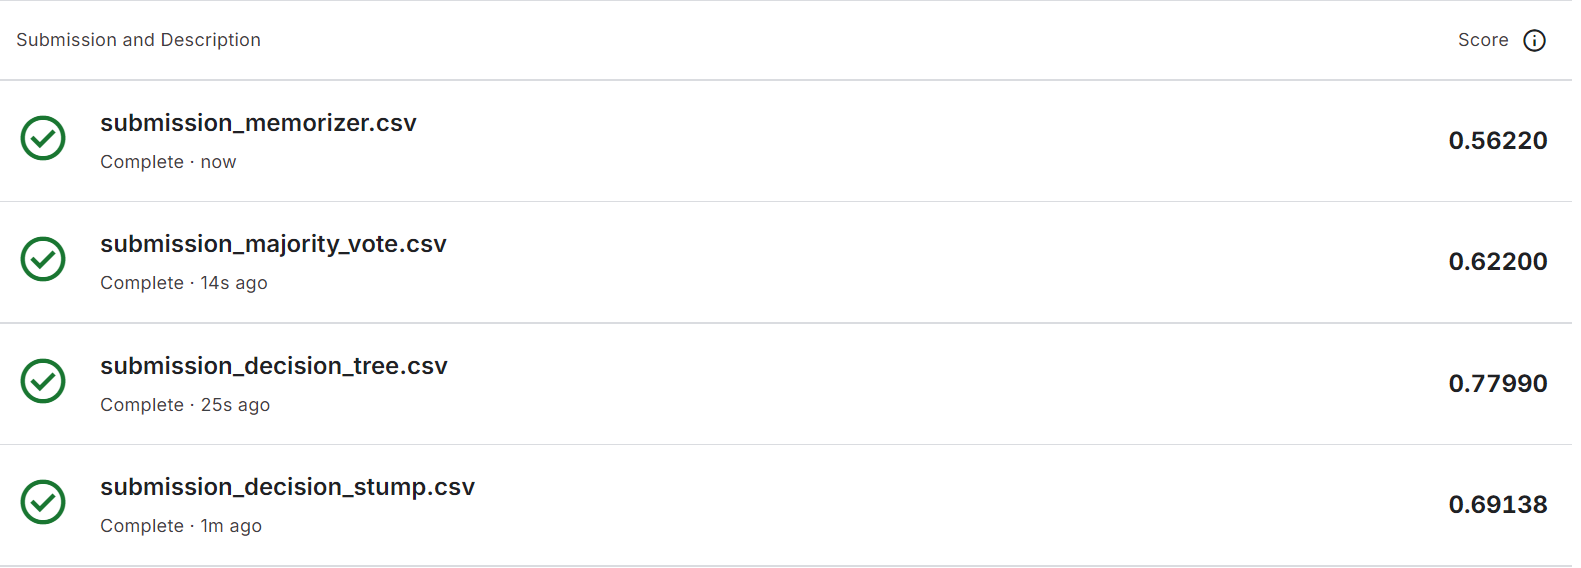

## LAB report

| Model | Training Accuracy | Validation Accuracy | Kaggle Score |
|---|---|---|---|
| Majority Vote | 0.6236 | 0.5866 | 0.62200 |
| Memorizer | 0.9761 | 0.5140 | 0.56220 |
| Decision Stump (best feature: **Fare**) | 0.8034 | 0.6983 | 0.69138 |
| Decision Tree | 0.8272 | 0.7989 | **0.77990** |

### 18.14 Kaggle Submission Score Sheet

- Student Name: `RAFAY SIDDIQUI`
- Roll Number: `K240009`
- Kaggle Username: `k240009rfq`
- Majority Vote Accuracy: **0.6236** (training) / 0.5866 (validation) / 0.62200 (Kaggle)
- Memorizer Training Accuracy: **0.9761**
- Best Decision Stump Accuracy: **0.8034** (feature: Fare)
- Decision Tree Validation Accuracy: **0.7989**
- Final Kaggle Score: **0.77990**
- Kaggle Rank: -
- Best Model: **Decision Tree**

**Why did you select it?**

The Decision Tree (max_depth=3) is the best model because it achieves the highest validation accuracy (0.7989) and Kaggle score (0.7799) by combining Pclass, Sex, Age, and Fare with constrained depth to generalize well on unseen data.

- **Decision Tree (0.7799)**: Captures multi-feature interactions while controlling depth to prevent overfitting.
- **Decision Stump (0.6914)**: Improves on the baseline using a single feature (Fare), but lacks multi-variable context.
- **Majority Vote (0.6220)**: Acts as a simple baseline by predicting only the most frequent class.
- **Memorizer (0.5622)**: Overfits severely, failing to generalize to new data and scoring worse than the naive baseline.